# Volcanic Field Simulations

Notebook to:
+ perform leave-k-out analyses on observed vent data
+ generate a synthetic dataset of vents within a user-defined volcanic field
+ analyse the results from both analyses
+ generate summary figures

Uses the `volcanicfieldsim` module.

Please cite: Miller et al. (submitted)

Full citation: <>

__________
Last modified: 6 May 2026

## Imports

In [27]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import importlib
import volcanicfieldsim as vfs
importlib.reload(vfs)
mpl.rcParams['font.family'] = 'Arial'

## AVF Ellipse Parameters

In [ ]:
startrect = (28884, 16481) # major x full minor (m) from Spörli & Eastwood 1997
center = (76614, 71891)
rotationdeg = 90 - 2.6
boundingellipse = {
    'center': center,
    'a': startrect[0] / 2,
    'b': startrect[1] / 2,
    'rotationdeg': rotationdeg
}
unitscale = 1.0 # everything in metres

# set the seed
baseseed = 123


## Observed Data Analaysis

### Load observed data and calulculate the hull info

In [ ]:
# read in vent data
vents = pd.read_csv('./Data/AVF vent ages and locations.csv')

# calculate hull info for all vents and save output to a CSV file
vents = vfs.sequentialhullinfo(vents, 
                               startrect = startrect,
                               center = center,
                               rotationdeg = rotationdeg,
                               savepath='./Outputs/AVFvents hull areas and distances.csv')

# remove first Rangitoto vent
vents = vents[vents['name'] != 'Rangitoto1']

# remove vents without ages
vents = vents.dropna(subset=['age'])

# subset young vents (< 63 ka)
youngvents = vents[vents['age'] < 63]

# print number of vents
print(f"Number of vents with ages: {len(vents)}")
print(f"Number of young vents (< 63 ka): {len(youngvents)}")

Number of vents with ages: 51
Number of young vents (< 63 ka): 35


### Run the leave-k-out analyses

In [18]:
# Run the analysis for all permutations of both leave-1-out and leave-2-out
points = vents[['easting','northing']].to_numpy(float)
results = vfs.withholdkensemble(points, k=[1,2], replacement=False)

# Summarize the results in terms of the buffer distance required to capture a target percentile
# of withheld vents (e.g., here, we specify 95% and 99%)
summaries_buff = vfs.summarizewithholdk(results, target_percentile=[0.95, 0.99])
target_buffer_m_k1 = summaries_buff[0.95][1]['target_buffer_m']
target_buffer_m_k2 = summaries_buff[0.95][2]['target_buffer_m']
print(f"Target buffer distance for 95% coverage with leave-1-out: {target_buffer_m_k1:.2f} m")
print(f"Target buffer distance for 95% coverage with leave-2-out: {target_buffer_m_k2:.2f} m")

# Summarize the results in terms of the percentile of vents within a specified target buffer
# (e.g., here, we specify a buffer of 0 m, which is equivalent to asking what percent 
# of vents are within the existing hull)
summaries_pct = vfs.summarizewithholdk(results, target_buffer_m=0)
pct_k1 = summaries_pct[0][1]['target_percentile']
pct_k2 = summaries_pct[0][2]['target_percentile']
print(f"Percent of vents within the existing hull (i.e., 0 m buffer) with leave-1-out: {pct_k1:.2f}%")
print(f"Percent of vents within the existing hull (i.e., 0 m buffer) with leave-2-out: {pct_k2:.2f}%")


Target buffer distance for 95% coverage with leave-1-out: 1576.73 m
Target buffer distance for 95% coverage with leave-2-out: 1783.98 m
Percent of vents within the existing hull (i.e., 0 m buffer) with leave-1-out: 0.75%
Percent of vents within the existing hull (i.e., 0 m buffer) with leave-2-out: 0.74%


In [ ]:
# Get the results for leave-k-out with target buffers ranging between 0 and 12000 m 
# in 500 m increments (data used in Figure 9)
target_buffer_m = np.arange(0, 12001, 500)
summaries = vfs.summarizewithholdk(results, target_buffer_m=target_buffer_m)

# Save the summaries to a data frame
summary_df = pd.DataFrame({
    'target_buffer_m': target_buffer_m,
    'pct_k1': [summaries[b][1]['target_percentile'] for b in target_buffer_m],
    'pct_k2': [summaries[b][2]['target_percentile'] for b in target_buffer_m],
})

# Save the data frame to a CSV file
summary_df.to_csv('./Outputs/AVF withhold-k buffers.csv', index=False)


In [ ]:
# Get the results for leave-k-out with the same target buffers for only those permutations
# where all withheld vents are young (<63 ka) (data used in Figure 9)
young_idx = youngvents.index.to_numpy()
results_young = (
    results
    .groupby('simid')
    .filter(lambda g: np.all(np.isin(g['withheldindex'], young_idx)))
)
summary_young = vfs.summarizewithholdk(results_young, target_buffer_m=target_buffer_m)

# Save the summaries to a data frame
summary_young_df = pd.DataFrame({
    'target_buffer_m': target_buffer_m,
    'pct_k1': [summary_young[b][1]['target_percentile'] for b in target_buffer_m],
    'pct_k2': [summary_young[b][2]['target_percentile'] for b in target_buffer_m],
})

# Save the data frame to a CSV file
summary_young_df.to_csv('./Outputs/AVF withhold-k buffers (all vents, young results).csv', index=False)

## Synthetic dataset

### Run ensemble

In [ ]:
# select the number of iterations
nsims = 1000

# select the number of eruptions in each iteration
neruptions = 250

# run the simulation and compute percentiles for the synthetic vents
syntheticventsens = vfs.runensemble(
    n_sims=nsims, n_eruptions=neruptions, coordsystem='cartesian',
    center=center, startrect=startrect, rotationdeg=rotationdeg,
    unitscale=unitscale, baseseed=baseseed)
syntheticventspctls = vfs.computepercentiles(syntheticventsens,
                                             percentiles=[2.5, 16, 50, 84, 97.5, 100])
syntheticventsens.head()


,simid,t,x,y,hullarea,arearatio,distprev,withinprevhull,disttoprevhull
0,1,1,74726.049798,79446.306933,0.000000e+00,0.000000,NaN,NaN,NaN
1,1,2,74736.550661,79722.992639,0.000000e+00,0.000000,276.884900,False,276.884900
2,1,3,70367.567695,62689.821046,5.149861e+05,0.001377,17584.565580,False,17314.045903
3,1,4,76805.652183,75819.642129,2.614852e+07,0.069938,14623.307886,False,2925.577415
4,1,5,76216.056699,75003.952998,2.614852e+07,0.069938,1006.464898,True,0.000000


### Plot results

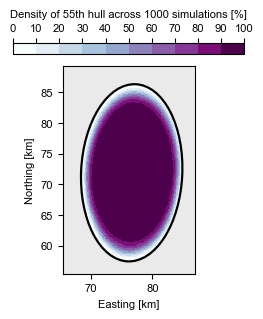

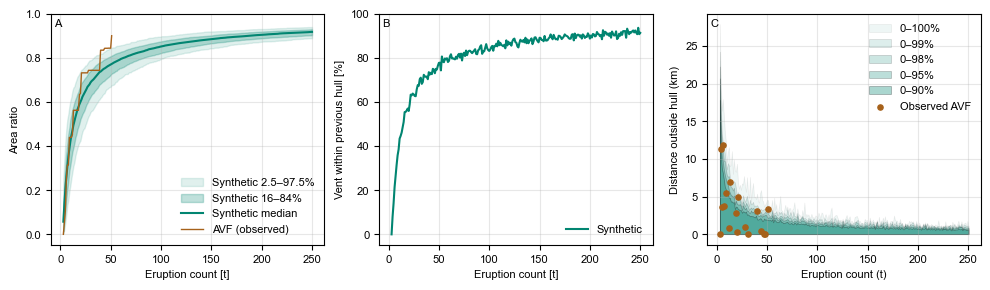

[<Figure size 400x300 with 2 Axes>, <Figure size 1200x300 with 3 Axes>]

In [22]:
# Plot a spatial figure showing the synthetic hulls at t=55 in relation to the starting ellipse and 
# a temporal figure showing the synthetic and observed hull area ratios, percent of synthetic vents 
# inside the prior convex hull, and distance of vents outside the hull through time (Figure 7)
hullalpha = 1/nsims
figures = [
    ('Spatial', ['spatial']),
    ('Temporal', ['arearatio', 'prctinside', 'distanceoutside'])
]
vfs.summaryplots(
    ensemble=syntheticventsens,
    percentiles=syntheticventspctls,
    observed=vents,
    boundingellipse=boundingellipse,
    figures=figures,
    savefigs=True,
    hullalpha=hullalpha
)


### Estimate probability of 'next' eruption being within current convex hull

In [ ]:
# Determine the percent of synthetic vents that are within the prior convex hull at each time step 
# between t=52 and t=55 (i.e., the potential 'next' eruption within the AVF)
tmin, tmax = 52, 55
percent_inside = (
    syntheticventsens
    .loc[
        (syntheticventsens['t'] >= tmin) &
        (syntheticventsens['t'] <= tmax),
        ['t', 'withinprevhull']
    ]
    .assign(withinprevhull=lambda d: d['withinprevhull'].astype(bool))
    .groupby('t')['withinprevhull']
    .mean()
    * 100
)
print(percent_inside)

t
52    74.3
53    80.6
54    78.4
55    78.0
Name: withinprevhull, dtype: float64


### Explore how buffers impact probability

In [26]:
# Determine the percentage of synthetic vents within a target buffer distance at t=52 with 
# buffers ranging between 0m and 12000m at a 500m increment (data used in Figure 9)

# define target buffers
buffers_m = np.arange(0, 12001, 500) 

# extract synthetic distances at t = 52
t0 = 52
dist_52 = (
    syntheticventsens
    .loc[syntheticventsens['t'] == t0, 'disttoprevhull']
    .astype(float)
    .to_numpy()
)

# compute percent within each buffer
percent_within = [
    (dist_52 <= b).mean() * 100.0
    for b in buffers_m
]

# assemble results
df_buffer_coverage = pd.DataFrame({
    'buffer_m': buffers_m,
    'percent_within_hull': percent_within
})

# save to CSV
df_buffer_coverage.to_csv('./Outputs/Synthetic buffers.csv', index=False)

### Explore how the starting elipse size impacts results

In [ ]:
# create a buffered bounding ellipses (+2 km and +5 km)
a = startrect[0] / 2
b = startrect[1] / 2
ellipse_buff = [2000, 5000]
buffered_ellipses = {
    buff: {
        "center": center,
        "a": a + buff,
        "b": b + buff,
        "rotationdeg": rotationdeg,
    }
    for buff in ellipse_buff}
bufferseed = {
    2000: 20001,
    5000: 50001,
}

# re-run the simulation for each buffered ellipse
ensembles = {}
ensembles[0] = syntheticventsens
for buff, ell in buffered_ellipses.items():
    ensembles[buff] = vfs.runensemble(
        n_sims=nsims,
        n_eruptions=neruptions,
        coordsystem="cartesian",
        center=center,
        startrect=(2 * ell["a"], 2 * ell["b"]),  # full major/minor
        rotationdeg=ell["rotationdeg"],
        unitscale=unitscale,
        baseseed=bufferseed[buff]
    )



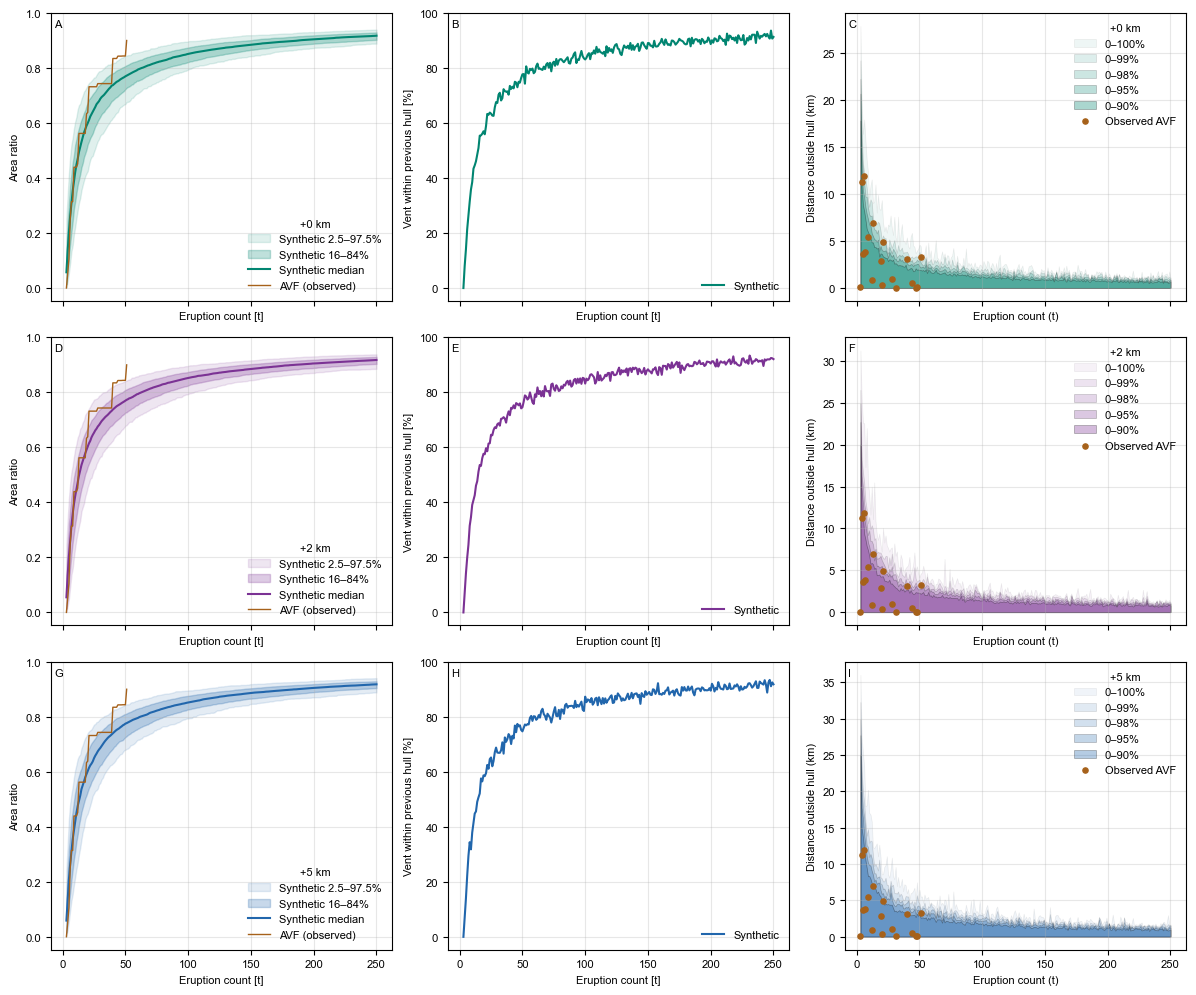

In [ ]:
# plot results (Figure A1)
fig= vfs.ensembleplots(
    ensembles=ensembles,
    observed=vents,
    mode="separate",
)

### Explore distance to previous eruption

Lower 2.5th percentile of distance to previous vents: 1801.83 m
Lower 5th percentile of distance to previous vents: 2584.03 m


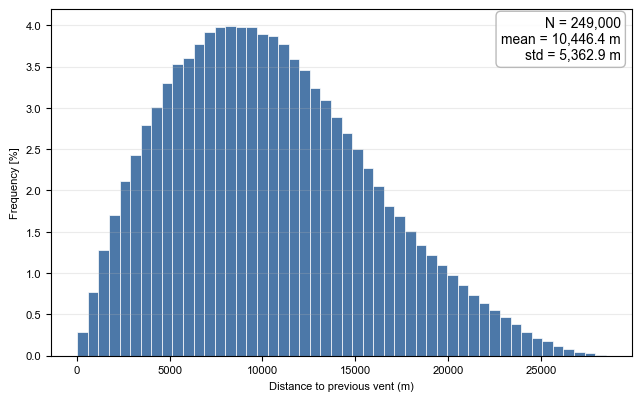

In [ ]:
# Calculate the lower 2.5 and 5th percentile of the distance to previous vents across 
# the synthetic dataset (data used in Figure 8)
print(f"Lower 2.5th percentile of distance to previous vents: {np.percentile(syntheticventsens['distprev'].dropna(), 2.5):.2f} m")
print(f"Lower 5th percentile of distance to previous vents: {np.percentile(syntheticventsens['distprev'].dropna(), 5):.2f} m")

# plot the distribution of distances to previous vents across the synthetic dataset
fig = vfs.plotdistprevhist(syntheticventsens, bins=50)

# save full ensemble of distances to previous vents to a CSV file
syntheticventsens.loc[syntheticventsens['distprev'].notna(), ['simid', 't', 'distprev']] \
     .to_csv('Synthetic distance to previous vent.csv', index=False)
